# 现代卷积神经网络

## 深度卷积神经网络(AlexNet)

当⼈们和机器学习研究⼈员交谈时，会发现机器学习研究⼈员相信机器学习既重要⼜美丽：优雅的理论去证明各种模型的性质。机器学习是⼀个正在蓬勃发展、严谨且⾮常有⽤的领域。然⽽，当⼈们和计算机视觉研究⼈员交谈，会听到⼀个完全不同的故事。计算机视觉研究⼈员会告诉⼀个诡异事实————推动领域进步的是数据特征，⽽不是学习算法。计算机视觉研究⼈员相信，从对最终模型精度的影响来说，更⼤或更⼲净的数据集、或是稍微改进的特征提取，⽐任何学习算法带来的进步要⼤得多。（我也更认同后者）

### AlexNet

AlexNet通过暂退法控制全连接层的模型复杂度，⽽LeNet只使⽤了权重衰减(正则化)。为了进⼀步扩充数据，AlexNet在训练时增加了⼤量的图像增强数据，如翻转、裁切和变⾊。这使得模型更健壮，更⼤的样本量有效地减少了过拟合。

In [2]:
import torch
from torch import nn
from d2l import torch as d2l

net = nn.Sequential(
    # 这里使用一个11*11的更大窗口来捕捉对象。
    # 同时，步幅为4，以减少输出的高度和宽度。
    # 另外，输出通道的数目远大于LeNet
    nn.Conv2d(1, 96, kernel_size=11, stride=4, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    # 减小卷积窗口，使用填充为2来使得输入与输出的高和宽一致，且增大输出通道数
    nn.Conv2d(96, 256, kernel_size=5, padding=2), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    # 使用三个连续的卷积层和较小的卷积窗口。
    # 除了最后的卷积层，输出通道的数量进一步增加。
    # 在前两个卷积层之后，汇聚层不用于减少输入的高度和宽度
    nn.Conv2d(256, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(384, 256, kernel_size=3, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    nn.Flatten(),
    # 这里，全连接层的输出数量是LeNet中的好几倍。使用dropout层来减轻过拟合
    nn.Linear(6400, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(4096, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    # 最后是输出层。由于这里使用Fashion-MNIST,所以类别数为10
    nn.Linear(4096, 10)
)

In [3]:
X = torch.randn(1, 1, 224, 224)
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__, 'output shape:\t', X.shape)

Conv2d output shape:	 torch.Size([1, 96, 54, 54])
ReLU output shape:	 torch.Size([1, 96, 54, 54])
MaxPool2d output shape:	 torch.Size([1, 96, 26, 26])
Conv2d output shape:	 torch.Size([1, 256, 26, 26])
ReLU output shape:	 torch.Size([1, 256, 26, 26])
MaxPool2d output shape:	 torch.Size([1, 256, 12, 12])
Conv2d output shape:	 torch.Size([1, 384, 12, 12])
ReLU output shape:	 torch.Size([1, 384, 12, 12])
Conv2d output shape:	 torch.Size([1, 256, 12, 12])
ReLU output shape:	 torch.Size([1, 256, 12, 12])
MaxPool2d output shape:	 torch.Size([1, 256, 5, 5])
Flatten output shape:	 torch.Size([1, 6400])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 10])


### 读取数据集

In [4]:
batch_size = 128
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=224)

### 训练AlexNet

与之前的LeNet相⽐，这⾥的主要变化是使⽤更⼩的学习速率训练，这是因为⽹络更深更⼴、图像分辨率更⾼，训练卷积神经⽹络就更昂贵。

loss 0.328, train acc 0.881, test acc 0.878
90.2 examples/sec on cpu


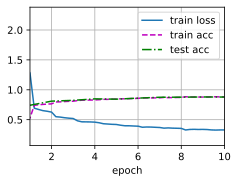

In [5]:
lr, num_epochs = 0.01, 10
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

### 练习

修改批量大小，并观察模型精度和GPU显存变化。

分别对比batch_size为64，128，512时的模型精度和GPU显存变化。\
batch_size=64，显存占用为：3.74GB，模型精度：loss 0.274, train acc 0.898, test acc 0.895\
batch_size=128，显存占用为：7.93GB，模型精度：loss 0.324, train acc 0.880, test acc 0.886\
batch_size=512，显存占用为：7.93GB，模型精度：loss 0.504, train acc 0.811, test acc 0.823\

    在上面的实验中可以看出，batch_size越大运行所需要的显存就越多，模型的精度也会降低。

## 使用块的网络(VGG)

在下⾯的⼏个章节中，我们将介绍⼀些常⽤于设计深层神经⽹络的启发式概念。

### VGG块

经典卷积神经⽹络的基本组成部分是下⾯的这个序列：
1. 带填充以保持分辨率的卷积层；
2. ⾮线性激活函数，如ReLU；
3. 汇聚层，如最⼤汇聚层。

⽽⼀个VGG块与之类似，由⼀系列卷积层组成，后⾯再加上⽤于空间下采样的最⼤汇聚层。

In [6]:
import torch
from torch import nn
from d2l import torch as d2l

def vgg_block(num_convs, in_channels, out_channels):
    layers = []
    for _ in range(num_convs):
        layers.append(nn.Conv2d(in_channels, out_channels,
                                kernel_size=3, padding=1))
        layers.append(nn.ReLU())
        in_channels = out_channels
    layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
    return nn.Sequential(*layers)

### VGG网络

In [7]:
# 每个VGG块里卷积层个数和输出通道数
conv_arch = ((1, 64), (1, 128), (2, 256), (2, 512), (2, 512))

In [8]:
def vgg(conv_arch):
    conv_blks = []
    in_channels = 1
    # 卷积层部分
    for (num_convs, out_channels) in conv_arch:
        conv_blks.append(vgg_block(num_convs, in_channels, out_channels))
        in_channels = out_channels

    return nn.Sequential(
        *conv_blks, nn.Flatten(),
        # 全链接层部分
        nn.Linear(out_channels * 7 * 7, 4096), nn.ReLU(), nn.Dropout(0.5),
        nn.Linear(4096, 4096), nn.ReLU(), nn.Dropout(0.5),
        nn.Linear(4096, 10)
    )

net = vgg(conv_arch)

In [9]:
X = torch.randn(size=(1, 1, 244, 244))
for blk in net:
    X = blk(X)
    print(blk.__class__.__name__, 'output shape:\t', X.shape)

Sequential output shape:	 torch.Size([1, 64, 122, 122])
Sequential output shape:	 torch.Size([1, 128, 61, 61])
Sequential output shape:	 torch.Size([1, 256, 30, 30])
Sequential output shape:	 torch.Size([1, 512, 15, 15])
Sequential output shape:	 torch.Size([1, 512, 7, 7])
Flatten output shape:	 torch.Size([1, 25088])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 10])


### 训练模型

In [10]:
ratio = 4
small_conv_arch = [(pair[0], pair[1] // ratio) for pair in conv_arch]
net = vgg(small_conv_arch)

loss 0.169, train acc 0.938, test acc 0.923
74.1 examples/sec on cpu


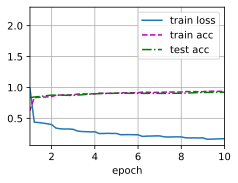

In [11]:
lr, num_epochs, batch_size = 0.05, 10, 128
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=224)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

## 网络中的网络(NiN)

### NiN块

In [12]:
import torch
from torch import nn
from d2l import torch as d2l

def nin_block(in_channels, out_channels, kernel_size, strides, padding):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, strides, padding),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1), nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1), nn.ReLU()
    )

### NiN模型

NiN和AlexNet之间的⼀个显著区别是NiN完全取消了全连接层。相反，NiN使⽤⼀个NiN块，其输出通道数等于标签类别的数量。最后放⼀个全局平均汇聚层（global average pooling layer），⽣成⼀个对数⼏率（logits）。NiN设计的⼀个优点是，它显著减少了模型所需参数的数量。然⽽，在实践中，这种设计有时会增加训练模型的时间。

In [15]:
net = nn.Sequential(
    nin_block(1, 96, kernel_size=11, strides=4, padding=0),
    nn.MaxPool2d(3, stride=2),
    nin_block(96, 256, kernel_size=5, strides=1, padding=2),
    nn.MaxPool2d(3, stride=2),
    nin_block(256, 384, kernel_size=3, strides=1, padding=1),
    nn.MaxPool2d(3, stride=2),
    nn.Dropout(0.5),
    # 标签类别数是10
    nin_block(384, 10, kernel_size=3, strides=1, padding=1),
    nn.AdaptiveAvgPool2d((1, 1)),
    # 将四维的输出转成二维的输出，其形状为(批量大小，10)
    nn.Flatten()
)

In [16]:
X = torch.rand(size=(1, 1, 224, 224))
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__, 'output shape:\t', X.shape)

Sequential output shape:	 torch.Size([1, 96, 54, 54])
MaxPool2d output shape:	 torch.Size([1, 96, 26, 26])
Sequential output shape:	 torch.Size([1, 256, 26, 26])
MaxPool2d output shape:	 torch.Size([1, 256, 12, 12])
Sequential output shape:	 torch.Size([1, 384, 12, 12])
MaxPool2d output shape:	 torch.Size([1, 384, 5, 5])
Dropout output shape:	 torch.Size([1, 384, 5, 5])
Sequential output shape:	 torch.Size([1, 10, 5, 5])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 10, 1, 1])
Flatten output shape:	 torch.Size([1, 10])


### 训练模型

In [ ]:
lr, num_epochs, batch_size = 0.1, 10, 128
train_iter, test_iter = d2l.load_data_mnist(batch_size, resize=224)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

## 含并行链接的网络(GoogLeNet)

⼀个重点是解决了什么样⼤⼩的卷积核最合适的问题。毕竟，以前流⾏的⽹络使⽤⼩到1 × 1，⼤到11 × 11的卷积核。本⽂的⼀个观点是，有时使⽤不同⼤⼩的卷积核组合是有利的。

### Inception块

<div align="center">
    <img src="../img/Inception块架构.png">
<div>

在Inception块中，通常调整的超参数是每层输出通道数。

In [19]:
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

class Inception(nn.Module):
    # c1 -- c4 是每条路径的输出通道数
    def __init__(self, in_channels, c1, c2, c3, c4, **kwargs):
        super(Inception, self).__init__(**kwargs)
        # 线路1，单1x1卷积层
        self.p1_1 = nn.Conv2d(in_channels, c1, kernel_size=1)
        # 线路2，1x1卷积后接3x3卷积层
        self.p2_1 = nn.Conv2d(in_channels, c2[0], kernel_size=1)
        self.p2_2 = nn.Conv2d(c2[0], c2[1], kernel_size=3, padding=1)
        # 线路3，1x1卷积层后接5x5卷积层
        self.p3_1 = nn.Conv2d(in_channels, c3[0], kernel_size=1)
        self.p3_2 = nn.Conv2d(c3[0], c3[1], kernel_size=5, padding=2)
        # 线路4，3x3最大汇聚层后接1x1卷积层
        self.p4_1 = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
        self.p4_2 = nn.Conv2d(in_channels, c4, kernel_size=1)

    def forward(self, x):
        p1 = F.relu(self.p1_1(x))
        p2 = F.relu(self.p2_2(F.relu(self.p2_1(x))))
        p3 = F.relu(self.p3_2(F.relu(self.p3_1(x))))
        p4 = F.relu(self.p4_2(self.p4_1(x)))
        # 在通道维度上连结输出
        return torch.cat((p1, p2, p3, p4), dim=1)

那么为什么GoogLeNet这个⽹络如此有效呢？⾸先我们考虑⼀下滤波器（filter）的组合，它们可以⽤各种滤波器尺⼨探索图像，这意味着不同⼤⼩的滤波器可以有效地识别不同范围的图像细节。同时，我们可以为不同的滤波器分配不同数量的参数。

### GoodLeNet模型

In [20]:
b1 = nn.Sequential(nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
                    nn.ReLU(),
                    nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

In [21]:
b2 = nn.Sequential(nn.Conv2d(64, 64, kernel_size=1),
                    nn.ReLU(),
                    nn.Conv2d(64, 192, kernel_size=3, padding=1),
                    nn.ReLU(),
                    nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

第三个模块串联两个完整的Inception块。第⼀个Inception块的输出通道数为64 + 128 + 32 + 32 = 256，四个路径之间的输出通道数量⽐为64 : 128 : 32 : 32 = 2 : 4 : 1 : 1。第⼆个和第三个路径⾸先将输⼊通道的数量分别减少到96/192 = 1/2和16/192 = 1/12，然后连接第⼆个卷积层。第⼆个Inception块的输出通道数增加到128 + 192 + 96 + 64 = 480，四个路径之间的输出通道数量⽐为128 : 192 : 96 : 64 = 4 : 6 : 3 : 2。第⼆条和第三条路径⾸先将输⼊通道的数量分别减少到128/256 = 1/2和32/256 = 1/8。

In [22]:
b3 = nn.Sequential(Inception(192, 64, (96, 128), (16, 32), 32),
                    Inception(256, 128, (128, 192), (32, 96), 64),
                    nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

第四模块更加复杂，它串联了5个Inception块，其输出通道数分别是192 + 208 + 48 + 64 = 512、160 + 224 + 64 + 64 = 512、128 + 256 + 64 + 64 = 512、112 + 288 + 64 + 64 = 528和256 + 320 + 128 + 128 = 832。这些路径的通道数分配和第三模块中的类似，⾸先是含3×3卷积层的第⼆条路径输出最多通道，其次是仅含1×1卷积层的第⼀条路径，之后是含5×5卷积层的第三条路径和含3×3最⼤汇聚层的第四条路径。其中第⼆、第三条路径都会先按⽐例减⼩通道数。这些⽐例在各个Inception块中都略有不同。

In [23]:
b4 = nn.Sequential(Inception(480, 192, (96, 208), (16, 48), 64),
                    Inception(512, 160, (112, 224), (24, 64), 64),
                    Inception(512, 128, (128, 256), (24, 64), 64),
                    Inception(512, 112, (144, 288), (32, 64), 64),
                    Inception(528, 256, (160, 320), (32, 128), 128),
                    nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

第五模块包含输出通道数为256 + 320 + 128 + 128 = 832和384 + 384 + 128 + 128 = 1024的两个Inception块。其中每条路径通道数的分配思路和第三、第四模块中的⼀致，只是在具体数值上有所不同。需要注意的是，第五模块的后⾯紧跟输出层，该模块同NiN⼀样使⽤全局平均汇聚层，将每个通道的⾼和宽变成1。最后我们将输出变成⼆维数组，再接上⼀个输出个数为标签类别数的全连接层。

In [24]:
b5 = nn.Sequential(Inception(832, 256, (160, 320), (32, 128), 128),
                    Inception(832, 384, (192, 384), (48, 128), 128),
                    nn.AdaptiveAvgPool2d((1,1)),
                    nn.Flatten())

net = nn.Sequential(b1, b2, b3, b4, b5, nn.Linear(1024, 10))

In [25]:
X = torch.rand(size=(1, 1, 96, 96))
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape:\t', X.shape)

Sequential output shape:	 torch.Size([1, 64, 24, 24])
Sequential output shape:	 torch.Size([1, 192, 12, 12])
Sequential output shape:	 torch.Size([1, 480, 6, 6])
Sequential output shape:	 torch.Size([1, 832, 3, 3])
Sequential output shape:	 torch.Size([1, 1024])
Linear output shape:	 torch.Size([1, 10])


### 训练模型

KeyboardInterrupt: 

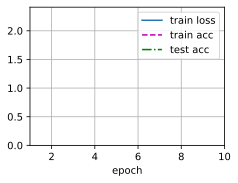

In [26]:
lr, num_epochs, batch_size = 0.1, 10, 128
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=96)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

## 批量规范化

本节将介绍批量规范化（batch normalization），这是⼀种流⾏且有效的技术，可持续加速深层⽹络的收敛速度。再结合在7.6节中将介绍的残差块，批量规范化使得研究⼈员能够训练100层以上的⽹络。

### 训练深层网络